#### **LAB 06: NHẬN DIỆN ẢNH (IMAGE DETECTION)**

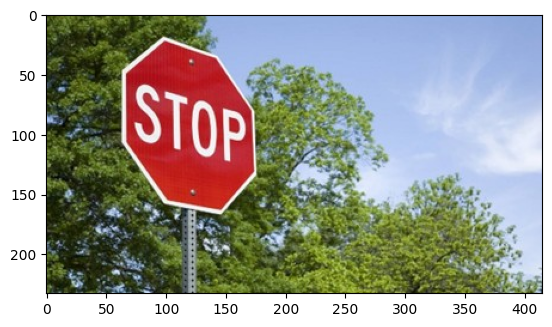

In [15]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("Image/Image.jpg")
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# dots that would look like STOP signs
stop_data = cv2.CascadeClassifier('haarcascade/haarcascade_frontalface_default.xml') #('/content/haarcascade_frontalcatface.xml')
found = stop_data.detectMultiScale(img_gray,minSize =(20, 20))
amount_found = len(found)
if amount_found != 0:

    for (x, y, width, height) in found:

        cv2.rectangle(img_rgb, (x, y),

                      (x + height, y + width),

                      (0, 255, 0), 5)

plt.imshow(img_rgb)

**1. Tham khảo đoạn code trên để tạo 1 đoạn code mới, kết hợp sử dụng hình ảnh sau và file: haarcascade_frontalface_default.xml (tải về từ đường dẫn bên dưới) để nhận diện khuôn mặt**

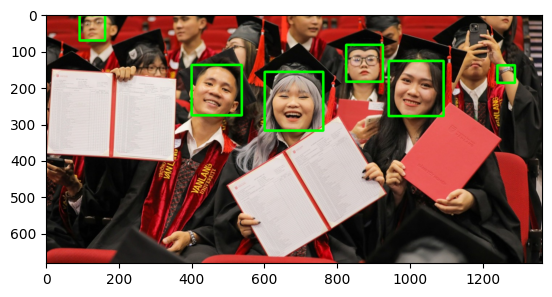

In [16]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("Image/Image2.jpg")
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

stop_data = cv2.CascadeClassifier('haarcascade/haarcascade_frontalface_default.xml')
found = stop_data.detectMultiScale(img_gray,minSize =(20, 20))
amount_found = len(found)
if amount_found != 0:

    for (x, y, width, height) in found:

        cv2.rectangle(img_rgb, (x, y),

                      (x + height, y + width),

                      (0, 255, 0), 5)

plt.imshow(img_rgb)

**2. Sử dụng các tham khảo và hình ảnh trên, có thể sử dụng thêm các ảnh tập thể, kỷ yếu khác để nhận diện: Nụ cười, tai, mắt, mũi, miệng, … của người trong bức ảnh.**

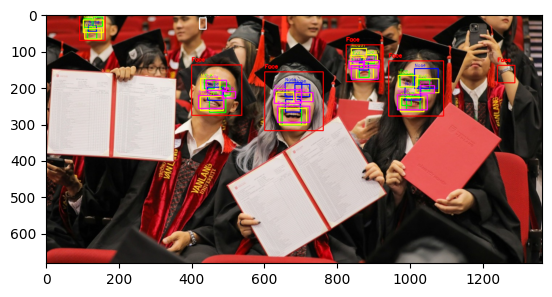

In [17]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("Image/Image2.jpg")
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Load Haar cascades for different features
face_cascade = cv2.CascadeClassifier('haarcascade/haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('haarcascade/haarcascade_eye.xml')
nose_cascade = cv2.CascadeClassifier('haarcascade/haarcascade_mcs_nose.xml')
mouth_cascade = cv2.CascadeClassifier('haarcascade/haarcascade_mcs_mouth.xml')
smile_cascade = cv2.CascadeClassifier('haarcascade/haarcascade_smile.xml')
leftear_cascade = cv2.CascadeClassifier('haarcascade/haarcascade_mcs_leftear.xml')
rightear_cascade = cv2.CascadeClassifier('haarcascade/haarcascade_mcs_rightear.xml')

# Detect faces
faces = face_cascade.detectMultiScale(img_gray, minSize=(20, 20))

for (x, y, w, h) in faces:
    # Draw rectangle around face and label
    cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (255, 0, 0), 2)
    cv2.putText(img_rgb, 'Face', (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
    
    # Define region of interest (ROI) for the face
    roi_gray = img_gray[y:y+h, x:x+w]
    roi_color = img_rgb[y:y+h, x:x+w]
    
    # Detect eyes within the face
    eyes = eye_cascade.detectMultiScale(roi_gray, minSize=(10, 10))
    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)
        cv2.putText(roi_color, 'Eye', (ex, ey-5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)
    
    # Detect nose within the face
    noses = nose_cascade.detectMultiScale(roi_gray, minSize=(10, 10))
    for (nx, ny, nw, nh) in noses:
        cv2.rectangle(roi_color, (nx, ny), (nx+nw, ny+nh), (0, 0, 255), 2)
        cv2.putText(roi_color, 'Nose', (nx, ny-5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)
    
    # Detect mouth within the face
    mouths = mouth_cascade.detectMultiScale(roi_gray, minSize=(10, 10))
    for (mx, my, mw, mh) in mouths:
        cv2.rectangle(roi_color, (mx, my), (mx+mw, my+mh), (255, 255, 0), 2)
        cv2.putText(roi_color, 'Mouth', (mx, my-5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 0), 1)
    
    # Detect smile within the face
    smiles = smile_cascade.detectMultiScale(roi_gray, minSize=(10, 10))
    for (sx, sy, sw, sh) in smiles:
        cv2.rectangle(roi_color, (sx, sy), (sx+sw, sy+sh), (255, 0, 255), 2)
        cv2.putText(roi_color, 'Smile', (sx, sy-5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 255), 1)

    # Detect left ears on the whole image
    leftears = leftear_cascade.detectMultiScale(img_gray, minSize=(10, 10))
    for (lx, ly, lw, lh) in leftears:
        cv2.rectangle(img_rgb, (lx, ly), (lx+lw, ly+lh), (0, 255, 255), 2)
        cv2.putText(img_rgb, 'Left Ear', (lx, ly-5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 255), 1)

    # Detect right ears on the whole image
    rightears = rightear_cascade.detectMultiScale(img_gray, minSize=(10, 10))
    for (rx, ry, rw, rh) in rightears:
        cv2.rectangle(img_rgb, (rx, ry), (rx+rw, ry+rh), (255, 255, 255), 2)
        cv2.putText(img_rgb, 'Right Ear', (rx, ry-5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)

plt.imshow(img_rgb)
plt.show()